##Description
This project analyzes a user dataset to understand demographic patterns
such as age distribution, gender distribution, and occupation trends.
The analysis includes data cleaning, feature engineering, and visualization.

In [121]:
# importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Working With CSV

## 1. Opening a local csv/tsv file

In [122]:
# here we just load and look how our look like
df=pd.read_csv('data/user.csv')
print(df)
print(df.shape)

    user_id|age|gender|occupation|zip_code
0                  1|24|M|technician|85711
1                       2|53|F|other|94043
2                      3|23|M|writer|32067
3                  4|24|M|technician|43537
4                       5|33|F|other|15213
..                                     ...
938                 939|26|F|student|33319
939           940|32|M|administrator|02215
940                 941|20|M|student|97229
941               942|48|F|librarian|78209
942                 943|22|M|student|77841

[943 rows x 1 columns]
(943, 1)


In [123]:
# for seprating values we can use sep parameter
df=pd.read_csv('user.csv',sep='|')
df


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


In [124]:
# Here we have unigue id for each row which is user_id let make it our index
df=pd.read_csv('user.csv',sep='|',index_col=['user_id'])
df

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213
...,...,...,...,...
939,26,F,student,33319
940,32,M,administrator,02215
941,20,M,student,97229


##Data Exploration

In [125]:
df.columns

Index(['age', 'gender', 'occupation', 'zip_code'], dtype='object')

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 943 entries, 1 to 943
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         943 non-null    int64 
 1   gender      943 non-null    object
 2   occupation  943 non-null    object
 3   zip_code    943 non-null    object
dtypes: int64(1), object(3)
memory usage: 36.8+ KB


In [127]:
df.describe()

,age
count,943.000000
mean,34.051962
std,12.192740
min,7.000000
25%,25.000000
50%,31.000000
75%,43.000000
max,73.000000


##Data Cleaning

In [128]:
# droping the duplicate data
df=df.drop_duplicates()

In [129]:
# checking null values
df.isna().sum()

,0
age,0
gender,0
occupation,0
zip_code,0


##Feature Engineering

In [130]:
print(df.columns)

Index(['age', 'gender', 'occupation', 'zip_code'], dtype='object')


In [131]:
# We can here catagorized our user on basics of their age
df['age_group']=pd.cut(
    df['age'],
    bins=[0,18,35,50,100],
    labels=['Teen','Young Adult','Adult','Senior']
)
df

/tmp/ipykernel_310/3588521572.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group']=pd.cut(


,age,gender,occupation,zip_code,age_group
user_id,,,,,
1,24,M,technician,85711,Young Adult
2,53,F,other,94043,Senior
3,23,M,writer,32067,Young Adult
4,24,M,technician,43537,Young Adult
5,33,F,other,15213,Young Adult
...,...,...,...,...,...
939,26,F,student,33319,Young Adult
940,32,M,administrator,02215,Young Adult
941,20,M,student,97229,Young Adult


## Data analysis

### Average age of our users

In [132]:
average_age=df["age"].mean()
print("Users average age " ,round(average_age,2))

Users average age  34.07


In [133]:
# Now check how many our users are Adult,teen and others
typeOfUser=df['age_group'].value_counts()
typeOfUser

,count
age_group,
Young Adult,513
Adult,266
Senior,104
Teen,53


### Most Common Occupation

In [134]:
df['occupation'].mode()[0]

'student'

### Gender distribution

In [135]:
gender_counts = df["gender"].value_counts()
print("Gender distribution:\n", gender_counts)

Gender distribution:
 gender
M    666
F    270
Name: count, dtype: int64


###Average Age by Occupation

In [136]:
# Average age on the basics of occupation
df.groupby('occupation')['age'].mean().sort_values(ascending=False)

,age
occupation,
retired,63.071429
doctor,43.571429
educator,41.914894
healthcare,41.562500
librarian,40.000000
administrator,38.746835
executive,38.718750
marketing,37.615385
lawyer,36.750000


# Data Visualization

## Age Distribution

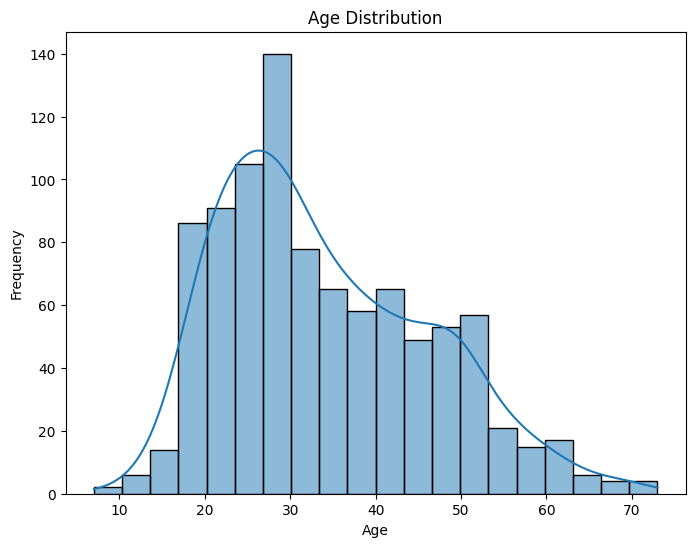

In [137]:
plt.figure(figsize=(8,6))
sns.histplot(df['age'],bins=20,kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## Age Group Distribution

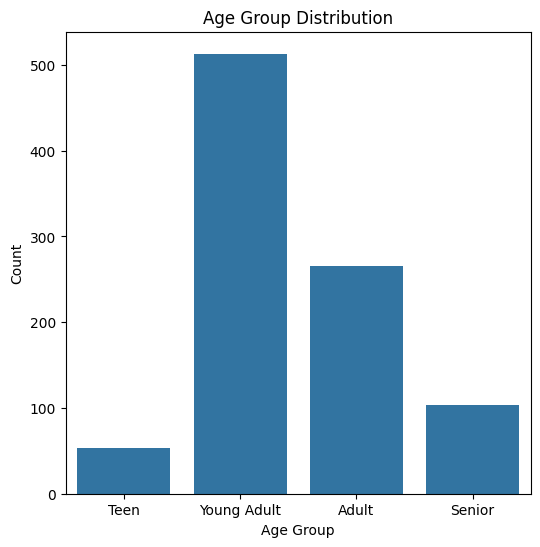

In [141]:
plt.figure(figsize=(6,6))
sns.countplot(x='age_group',data=df)
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

## Top 10 Occupations

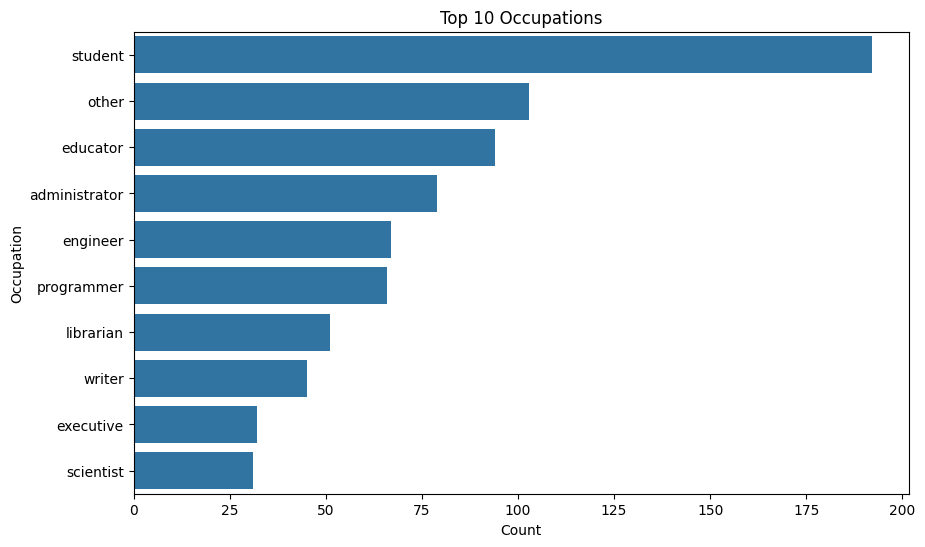

In [148]:
top10=df['occupation'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10.values,y=top10.index)
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.title('Top 10 Occupations')
plt.show()